# Quickstart - slide → features in a few commands (offline)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CraigMyles/raw2features/blob/main/notebooks/01_quickstart.ipynb)

The whole pipeline on a **synthetic slide** - no data to download, no Hugging Face token,
no GPU. You'll write a toy slide, segment + embed it, and *see* each step. For the same
walkthrough on a **real** H&E slide, see
[`02_visual_walkthrough.ipynb`](02_visual_walkthrough.ipynb).

In [1]:
# Bootstrap: works on Colab and a local install.
import importlib.util, subprocess, sys

IN_COLAB = "google.colab" in sys.modules
HAVE_PKG = importlib.util.find_spec("raw2features") is not None
EXTRAS = "zarr,image,torch,models"
SPEC = f"raw2features[{EXTRAS}]"  # PyPI; pin a version (==0.1.1) for reproducibility
if IN_COLAB or not HAVE_PKG:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", SPEC])

import os, glob, tempfile
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import raw2features
from raw2features.core.geometry import Point, Region, Size
from raw2features.readers.omezarr import OmeZarrReader

mpl.rcParams["figure.dpi"] = 72
WORK = tempfile.mkdtemp(prefix="r2f_quick_")
print("raw2features", raw2features.__version__, "| python", sys.version.split()[0])

raw2features 0.1.0 | python 3.12.3


## 1. Write a synthetic slide

`raw2features sample` writes a tiny OME-NGFF slide - a tissue-like blob with two H&E-ish
compartments (purple nuclei-rich → pink stroma) and a few gland-like rings. Synthetic, but
shaped so segmentation and the features have something to find.

wrote synthetic OME-Zarr slide: /tmp/r2f_quick_ca89l3t1/sample.ome.zarr
try:  raw2features embed /tmp/r2f_quick_ca89l3t1/sample.ome.zarr out/ -m resnet50 --device auto


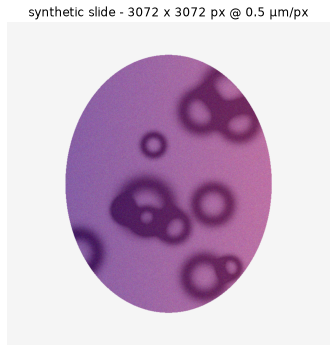

In [2]:
SLIDE = os.path.join(WORK, "sample.ome.zarr")
subprocess.check_call(["raw2features", "sample", SLIDE, "--size", "3072"])

with OmeZarrReader(SLIDE) as r:
    w0, h0 = r.level_dimensions[0]
    lvl = len(r.level_dimensions) - 1                 # smallest level for a quick view
    sw, sh = r.level_dimensions[lvl]
    thumb = r.read_region(Region(level=lvl, location=Point(0, 0), size=Size(sw, sh)))

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(thumb); ax.axis("off")
ax.set_title(f"synthetic slide - {w0} x {h0} px @ 0.5 µm/px")
plt.tight_layout(); plt.show()

## 2. Segment the tissue and lay down the patch grid

The built-in `thumbnail --overlay` runs Otsu tissue segmentation and tiles the tissue:
the **tint** is the kept tissue, the **green grid** is the patches the model will see -
the bright background is skipped.

plain: sample.thumbnail.png
overlay: sample.thumbnail.overlay.png
mpp: 2.0
max_px: None
read_level: 2
downsample: 4.0
size_wh: [768, 768]


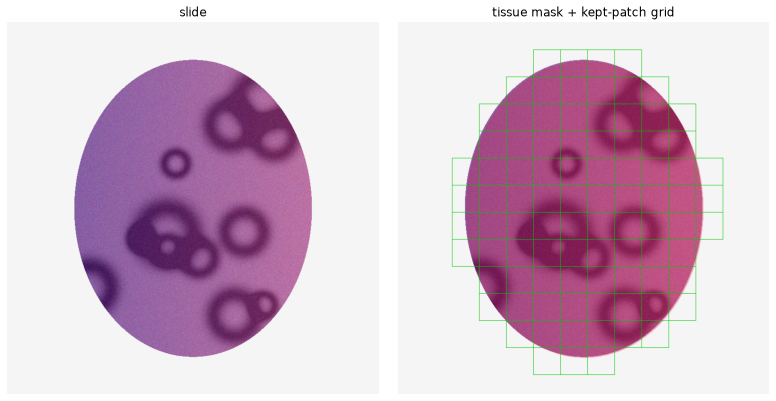

In [3]:
subprocess.check_call(["raw2features", "thumbnail", SLIDE, WORK + "/",
                       "--overlay", "--thumbnail-mpp", "2.0",
                       "--mpp", "0.5", "--patch-size", "224"])  # match the embed geometry
plain = glob.glob(os.path.join(WORK, "*.thumbnail.png"))[0]
overlay = glob.glob(os.path.join(WORK, "*.thumbnail.overlay.png"))[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, png, t in [(axes[0], plain, "slide"),
                   (axes[1], overlay, "tissue mask + kept-patch grid")]:
    ax.imshow(plt.imread(png)); ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Extract features

Embed the slide at exactly 0.5 µm/px with ResNet-50 on CPU - segment → tile → embed in one
command. The output is a compact, self-describing `.embeddings.zarr`.

In [4]:
OUT = os.path.join(WORK, "out")
MPP, PATCH, MODEL = 0.5, 224, "resnet50"
subprocess.check_call(["raw2features", "embed", SLIDE, OUT + "/",
                       "-m", MODEL, "--mpp", str(MPP), "--device", "cpu"])

from raw2features.core.store import open_grid  # selects the single grid (grids/<mpp>_<px>/)
store = os.path.join(OUT, "sample.embeddings.zarr")
g = open_grid(store)
coords = g["coords"][:]
feats = g["features"][MODEL][:].astype(np.float32)
print(f"{coords.shape[0]} patches  ->  {feats.shape[1]}-d ResNet-50 features each")

slide_id: sample
status: complete
grids: {'mpp0.5_px224': ['resnet50']}
output_uri: file:///tmp/r2f_quick_ca89l3t1/out/sample.embeddings.zarr
per_grid: [{'slide_id': 'sample', 'status': 'complete', 'n_patches': 90, 'models': ['resnet50'], 'models_added': ['resnet50'], 'models_skipped': [], 'slide_embeddings': {}, 'output_uri': 'file:///tmp/r2f_quick_ca89l3t1/out/sample.embeddings.zarr', 'geojson': None, 'thumbnail': None, 'elapsed_s': 3.18}]
elapsed_s: 3.72


90 patches  ->  2048-d ResNet-50 features each


## 4. See the patches, and the model's view

A few patches the model embedded, then every patch's feature vector projected to RGB by
PCA and painted onto its grid cell - the two compartments and the glands separate out, so
even this toy slide shows the features carry structure.

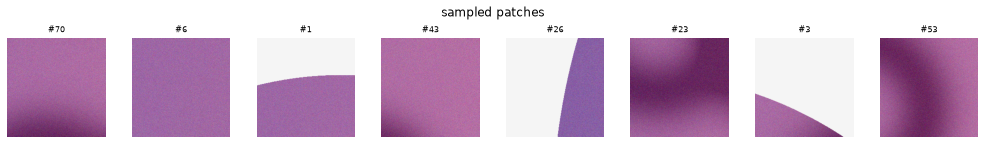

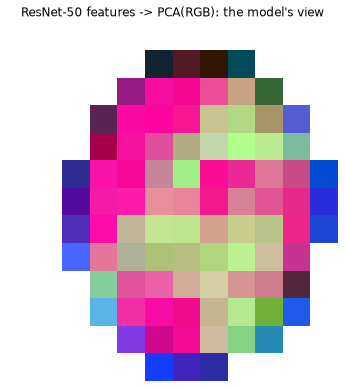

In [5]:
reader = OmeZarrReader(SLIDE).open()
plan = reader.level_for_mpp(MPP, PATCH)   # level + read size that lands on 0.5 µm/px
rng = np.random.default_rng(0)
pick = rng.choice(coords.shape[0], size=min(8, coords.shape[0]), replace=False)
fig, axes = plt.subplots(1, 8, figsize=(14, 2.0))
for ax, idx in zip(axes, pick):
    x, y = coords[idx]
    ax.imshow(reader.read_region(Region.patch(int(x), int(y), plan.read_px, plan.level)))
    ax.set_title(f"#{idx}", fontsize=8); ax.axis("off")
plt.suptitle("sampled patches"); plt.tight_layout(); plt.show()
reader.close()

# PCA(features) -> RGB, laid onto each patch's grid cell (one pixel per patch).
X = feats - feats.mean(0)
_, _, Vt = np.linalg.svd(X, full_matrices=False)      # rows of Vt are the principal directions
pc = X @ Vt[:3].T
rgb = (pc - pc.min(0)) / (np.ptp(pc, axis=0) + 1e-9)   # scale each component to [0, 1]
gi = g["grid_index"][:]                                # each patch's (row, col) in the grid
rows, cols = int(gi[:, 0].max()) + 1, int(gi[:, 1].max()) + 1
rgb_img = np.ones((rows, cols, 3))                     # white where there is no tissue
rgb_img[gi[:, 0], gi[:, 1]] = rgb
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(rgb_img, interpolation="nearest"); ax.axis("off")
ax.set_title("ResNet-50 features -> PCA(RGB): the model's view")
plt.tight_layout(); plt.show()

## That's the whole loop

**slide → tissue → patches → features**, offline. The output `.embeddings.zarr` is
self-describing and spec-validated - see
[`03_the_embeddings_store.ipynb`](03_the_embeddings_store.ipynb) for what's inside it and
the provenance it records. For the same tour on a real SurGen H&E slide pulled straight
from the BioImage Archive, see
[`02_visual_walkthrough.ipynb`](02_visual_walkthrough.ipynb).

---
**[raw2features](https://github.com/CraigMyles/raw2features)** · OME-Zarr WSIs → foundation-model embeddings · author **Craig Myles** · licence **MIT**

If you use raw2features, please cite it ([`CITATION.cff`](https://github.com/CraigMyles/raw2features/blob/main/CITATION.cff)). Pretrained encoders carry their own licences ([`MODEL_LICENSES.md`](https://github.com/CraigMyles/raw2features/blob/main/docs/MODEL_LICENSES.md)).